In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix


#Load MNIST
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

In [16]:
#Normalize
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0



# Flatten images: 28x28 -> 784
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

# Apply PCA: reduce 784 -> 50
pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [17]:
print("Original X_train shape:", X_train.shape)
print("PCA X_train shape:", X_train_pca.shape)
print("Original X_test shape:", X_test.shape)
print("PCA X_test shape:", X_test_pca.shape)

Original X_train shape: (60000, 784)
PCA X_train shape: (60000, 50)
Original X_test shape: (10000, 784)
PCA X_test shape: (10000, 50)


In [18]:
train_labels = to_categorical(Y_train, 10)
test_labels = to_categorical(Y_test, 10)

In [19]:
model_pca = models.Sequential([
    layers.Input(shape=(50,)),
    layers.Dense(500, activation='relu'),
    layers.Dense(250, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [20]:
model_pca.summary()
# Summary of the model architecture


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 500)            │        25,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 250)            │       125,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153,260 (598.67 KB)

 Trainable params: 153,260 (598.67 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model_pca.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
# training
history_pca = model_pca.fit(
    X_train_pca,
    train_labels,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9841 - loss: 0.0475 - val_accuracy: 0.9753 - val_loss: 0.1012
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9937 - loss: 0.0185 - val_accuracy: 0.9779 - val_loss: 0.1022
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9945 - loss: 0.0168 - val_accuracy: 0.9778 - val_loss: 0.1041
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9945 - loss: 0.0165 - val_accuracy: 0.9786 - val_loss: 0.1092
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9949 - loss: 0.0155 - val_accuracy: 0.9792 - val_loss: 0.0979
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9954 - loss: 0.0133 - val_accuracy: 0.9761 - val_loss: 0.1288
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9968 - loss: 0.0098 - val_accuracy: 0.9799 - val_loss: 0.1034
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9955 - loss: 0.0134 - val_accuracy: 0.

In [24]:
test_loss_pca, test_acc_pca = model_pca.evaluate(X_test_pca, test_labels, verbose=0)
print("PCA Model Test Accuracy:", test_acc_pca)

PCA Model Test Accuracy: 0.9782999753952026


In [25]:
y_pred_prob_pca = model_pca.predict(X_test_pca)
y_pred_pca = np.argmax(y_pred_prob_pca, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 975us/step


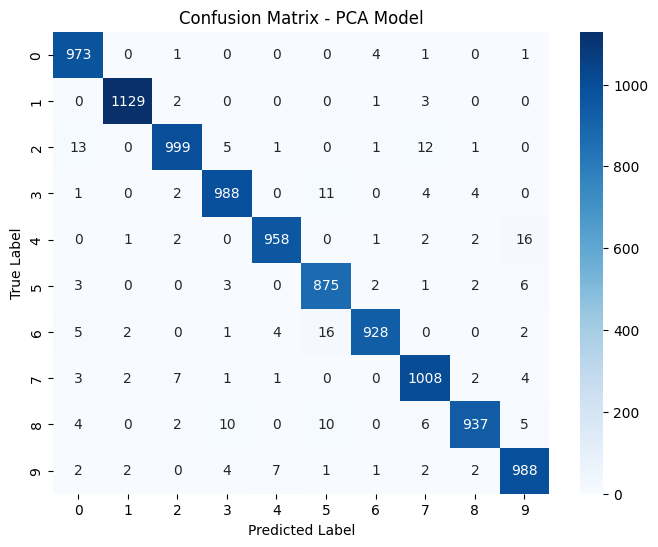

In [26]:
# Confusion Matrix
cm_pca = confusion_matrix(Y_test, y_pred_pca)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - PCA Model")
plt.show()

In [ ]:
# Observations:
# PCA achieves around 97.82999753952026% test accuracy, which is slightly lower than the original model without PCA.
# The confusion matrix shows that most digits are classified correctly, but there are some misclassifications, especially between similar digits (e.g., 4 and 9).
# Overall, PCA reduces the dimensionality of the data while retaining most of the variance, but it may lead to a slight drop in accuracy compared to using the full feature set.
# Due to dimentional reduction, we might have lost some important information, which could explain the drop in accuracy.